---
# Projetos de análise de dados
---

# Mercado de Criptomoedas

*Você foi contratado como um experiente trader, com sólidos conhecimentos em análise de dados, para apoiar uma empresa de investimentos que deseja atuar no mercado de criptomoedas. Seu primeiro desafio é analisar o comportamento do par BTC-USD (Bitcoin cotado em Dólares americanos). A empresa pretende tomar decisões estratégicas de investimento com base em evidências extraídas de dados históricos, buscando identificar padrões, tendências e possíveis oportunidades de compra e venda. Ao explorar o conjunto de dados, você percebe que há informações relevantes que podem ser utilizadas para compreender a variação de preços ao longo do tempo. Sua missão é realizar uma análise dos dados disponíveis e responder, com base nos dados do par BTC-USD, quais tendências podem ser identificadas e que estratégias de investimento poderiam ser sugeridas para operações futuras.*

Este estudo de caso foi inspirado no trabalho de [Cordeiro et al. (2025)](https://doi.org/10.5753/dsw.2025.247689) cujo código fonte está disponível para [download](https://github.com/jeovanereges/DSW2025).

Instação do pacote da API Finance para recuperar a base de dados.

`pip install yfinance --upgrade --no-cache-dir`

Uma breve explicção dos parametros usados na API:

- `"BTC-USD"` → símbolo do ativo (Bitcoin em dólares).
- `multi_level_index=False` → evita que o DataFrame venha com índice hierárquico.
- `start=start` → data inicial (variável definida anteriormente).
- `end=end` → data final (variável definida anteriormente).
- `interval="1d"` → frequência diária.
- `session=session` → usa uma sessão HTTP para performance/requisições (variável definida anteriormente).

In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from curl_cffi import requests

In [2]:
session = requests.Session(impersonate="chrome")
start = '2017-01-01' #AAAA-MM-DD
end = '2025-12-31'

dataset = yf.download("BTC-USD",\
                      multi_level_index=False, 
                      start=start, end=end, 
                      interval="1d", 
                      session=session)[["Open", "High", "Low", "Close"]]

[*********************100%***********************]  1 of 1 completed


## Análise Exploratória

In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3286 entries, 2017-01-01 to 2025-12-30
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    3286 non-null   float64
 1   High    3286 non-null   float64
 2   Low     3286 non-null   float64
 3   Close   3286 non-null   float64
dtypes: float64(4)
memory usage: 128.4 KB


In [4]:
dataset.head()

,Open,High,Low,Close
Date,,,,
2017-01-01,963.658020,1003.080017,958.698975,998.325012
2017-01-02,998.617004,1031.390015,996.702026,1021.750000
2017-01-03,1021.599976,1044.079956,1021.599976,1043.839966
2017-01-04,1044.400024,1159.420044,1044.400024,1154.729980
2017-01-05,1156.729980,1191.099976,910.416992,1013.380005


In [5]:
dataset.describe()

,Open,High,Low,Close
count,3286.000000,3286.000000,3286.000000,3286.000000
mean,33537.944309,34214.249399,32823.834814,33563.289246
std,32132.048389,32661.824711,31566.989292,32140.648268
min,775.177979,823.307007,755.755981,777.757019
25%,8041.255493,8219.481934,7838.148071,8044.845093
50%,22013.654297,22598.989258,21453.022461,22185.371094
75%,50646.193359,51861.505859,49046.175781,50685.168945
max,124752.140625,126198.070312,123196.046875,124752.531250


| Coluna |                          Descrição                          | Tipo    | Valores ausentes |
|--------|:-----------------------------------------------------------:|---------|------------------|
| Open   | Abertura: o primeiro preço  negociado no início do período. | float64 |        não       |
| High   |      Máxima: o maior preço  atingido durante o período.     | float64 |        não       |
| Low    |      Mínimo: o menor preço  atingido durante o período.     | float64 |        não       |
| Close  |  Fechamento: o último preço  negociado ao final do período. | float64 |        não       |

## Tratamento dos dados

Apenas o preço de fechamento é necessário para avaliar a variação do nível dos valores do ativo.

In [6]:
df_close = dataset['Close']
df_close.head()

Date
2017-01-01     998.325012
2017-01-02    1021.750000
2017-01-03    1043.839966
2017-01-04    1154.729980
2017-01-05    1013.380005
Name: Close, dtype: float64

A data deve ser movida para a coluna para facilitar a manipulação das datas.

In [7]:
df_close = df_close.reset_index()
df_close.head()

,Date,Close
0,2017-01-01,998.325012
1,2017-01-02,1021.750000
2,2017-01-03,1043.839966
3,2017-01-04,1154.729980
4,2017-01-05,1013.380005


As colunas Year e Month devem ser criadas para facilitar os cálculos.

In [8]:
df_close['Year'] = df_close['Date'].apply(lambda time: time.year)
df_close['Month'] = df_close['Date'].apply(lambda time: time.month)
df_close.head()

,Date,Close,Year,Month
0,2017-01-01,998.325012,2017,1
1,2017-01-02,1021.750000,2017,1
2,2017-01-03,1043.839966,2017,1
3,2017-01-04,1154.729980,2017,1
4,2017-01-05,1013.380005,2017,1


Apenas o preço de fechamento do mês é necessário para analisar analisar a variação do nível mensal. Por esse motivo, apenas a linha do último dia de cada mês é selecionada.

In [9]:
df_close = df_close[df_close['Date'].dt.is_month_end]
df_close

,Date,Close,Year,Month
30,2017-01-31,970.403015,2017,1
58,2017-02-28,1179.969971,2017,2
89,2017-03-31,1071.790039,2017,3
119,2017-04-30,1347.890015,2017,4
150,2017-05-31,2286.409912,2017,5
...,...,...,...,...
3133,2025-07-31,115758.203125,2025,7
3164,2025-08-31,108236.710938,2025,8
3194,2025-09-30,114056.085938,2025,9
3225,2025-10-31,109556.164062,2025,10


## Análise dos dados

Gráfico da variação do valor nível dos preços durante os alunos. O valor cresce com o passar dos anos.

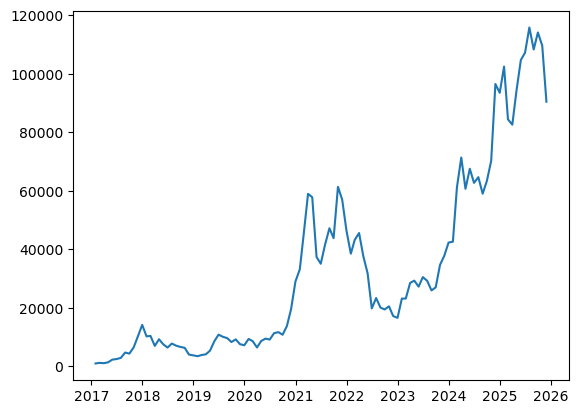

In [10]:
plt.plot(df_close['Date'], df_close['Close'])
plt.savefig('plot-Date-proj-cripto.png', dpi=300)
plt.show()

Agrupa os dados pelo par ano/mês (Year/Month). O valores selecionados são os de Close. Como há apenas um valor de fechamento para cada par, nenhum calculo é feito, é retornado apenas o valor do fechamento. Ou seja, qualquer agregação daria o mesmo resultado.

In [11]:
df_close_grouped = df_close.groupby(['Year', 'Month'])['Close'].max()
df_close_grouped.round(2)

Year  Month
2017  1           970.40
      2          1179.97
      3          1071.79
      4          1347.89
      5          2286.41
                 ...    
2025  7        115758.20
      8        108236.71
      9        114056.09
      10       109556.16
      11        90394.31
Name: Close, Length: 107, dtype: float64

Faz o pivoteamento do agrupamento para melhorar a visualização dos dados. Podemos observar que os valores crescem com o passar do tempo.

In [12]:
df_close_grouped.unstack()

Month,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
2017,970.403015,1179.969971,1071.790039,1347.890015,2286.409912,2480.840088,2875.340088,4703.390137,4338.709961,6468.399902,10233.599609,14156.400391
2018,10221.099609,10397.900391,6973.529785,9240.549805,7494.169922,6404.000000,7780.439941,7037.580078,6625.560059,6317.609863,4017.268555,3742.700439
2019,3457.792725,3854.785400,4105.404297,5350.726562,8574.501953,10817.155273,10085.627930,9630.664062,8293.868164,9199.584961,7569.629883,7193.599121
2020,9350.529297,8599.508789,6438.644531,8658.553711,9461.058594,9137.993164,11323.466797,11680.820312,10784.491211,13780.995117,19625.835938,29001.720703
2021,33114.359375,45137.769531,58918.832031,57750.175781,37332.855469,35040.835938,41626.195312,47166.687500,43790.894531,61318.957031,57005.425781,46306.445312
2022,38483.125000,43193.234375,45538.675781,37714.875000,31792.310547,19784.726562,23336.896484,20049.763672,19431.789062,20495.773438,17168.566406,16547.496094
2023,23139.283203,23147.353516,28478.484375,29268.806641,27219.658203,30477.251953,29230.111328,25931.472656,26967.916016,34667.781250,37712.746094,42265.187500
2024,42582.605469,61198.382812,71333.648438,60636.855469,67491.414062,62678.292969,64619.250000,58969.898438,63329.500000,70215.187500,96449.054688,93429.203125
2025,102405.023438,84373.007812,82548.914062,94207.312500,104638.093750,107135.335938,115758.203125,108236.710938,114056.085938,109556.164062,90394.312500,NaN


Cria a coluna **pct** que calcula a variação percentual entre os valores consecutivos do preço fechamento (Close).

In [13]:
df_close['pct'] = (df_close['Close'].pct_change()*100).round(2)
df_close

,Date,Close,Year,Month,pct
30,2017-01-31,970.403015,2017,1,NaN
58,2017-02-28,1179.969971,2017,2,21.60
89,2017-03-31,1071.790039,2017,3,-9.17
119,2017-04-30,1347.890015,2017,4,25.76
150,2017-05-31,2286.409912,2017,5,69.63
...,...,...,...,...,...
3133,2025-07-31,115758.203125,2025,7,8.05
3164,2025-08-31,108236.710938,2025,8,-6.50
3194,2025-09-30,114056.085938,2025,9,5.38
3225,2025-10-31,109556.164062,2025,10,-3.95


Gráfico da variação percentual (pct). Esse gráfico não parece útil.

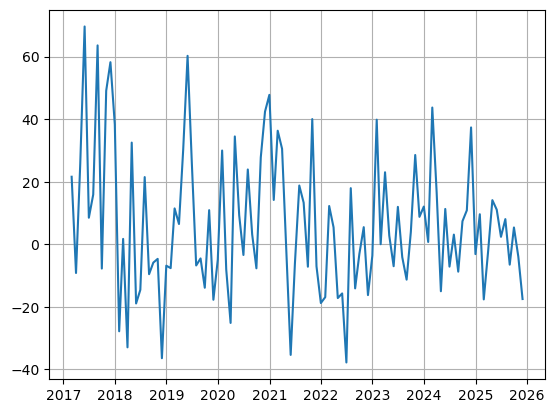

In [14]:
plt.plot(df_close['Date'], df_close['pct'])
plt.grid(True)
plt.savefig('plot-pct-proj-cripto.png', dpi=300)
plt.show()

Agrupa os dados pelo par ano/mês (Year/Month). O valores selecionados são os de ptc. Como há apenas um valor de pct para cada par, nenhum calculo é feito, é retornado apenas o valor do pct. Ou seja, qualquer agregação daria o mesmo resultado.

Faz o pivoteamento do agrupamento para melhorar a visualização dos dados. Podemos observar que os valores do pct variam de formas diferentes como passar to tempo.

In [15]:
df_close_grouped = df_close.groupby(['Year', 'Month'])['pct'].max()
df_close_grouped = df_close_grouped.unstack()
df_close_grouped

Month,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
2017,NaN,21.60,-9.17,25.76,69.63,8.50,15.90,63.58,-7.75,49.09,58.21,38.33
2018,-27.80,1.73,-32.93,32.51,-18.90,-14.55,21.49,-9.55,-5.85,-4.65,-36.41,-6.83
2019,-7.61,11.48,6.50,30.33,60.25,26.15,-6.76,-4.51,-13.88,10.92,-17.72,-4.97
2020,29.98,-8.03,-25.13,34.48,9.27,-3.41,23.92,3.16,-7.67,27.79,42.41,47.77
2021,14.18,36.31,30.53,-1.98,-35.35,-6.14,18.79,13.31,-7.16,40.03,-7.03,-18.77
2022,-16.89,12.24,5.43,-17.18,-15.70,-37.77,17.95,-14.09,-3.08,5.48,-16.23,-3.62
2023,39.84,0.03,23.03,2.78,-7.00,11.97,-4.09,-11.29,4.00,28.55,8.78,12.07
2024,0.75,43.72,16.56,-15.00,11.30,-7.13,3.10,-8.74,7.39,10.87,37.36,-3.13
2025,9.61,-17.61,-2.16,14.12,11.07,2.39,8.05,-6.50,5.38,-3.95,-17.49,NaN


Estiliza o dataframe para melhor a variação dos valores de pct. Agora é mais fácil observar quando o ativo cresceu ou diminuiu de um mês para outro.

In [16]:
labels = ['jan', 'fev', 'mar', 'abr', 'mai', 'jun', 'jul', 'ago', 'set',\
                                                      'out', 'nov','dez']
df_close_grouped.columns = labels
df_style = df_close_grouped.style.map(lambda v: 'background: lightcoral' \
                                       if v < 0 else 'background: lightblue')
df_style

,jan,fev,mar,abr,mai,jun,jul,ago,set,out,nov,dez
Year,,,,,,,,,,,,
2017,nan,21.600000,-9.170000,25.760000,69.630000,8.500000,15.900000,63.580000,-7.750000,49.090000,58.210000,38.330000
2018,-27.800000,1.730000,-32.930000,32.510000,-18.900000,-14.550000,21.490000,-9.550000,-5.850000,-4.650000,-36.410000,-6.830000
2019,-7.610000,11.480000,6.500000,30.330000,60.250000,26.150000,-6.760000,-4.510000,-13.880000,10.920000,-17.720000,-4.970000
2020,29.980000,-8.030000,-25.130000,34.480000,9.270000,-3.410000,23.920000,3.160000,-7.670000,27.790000,42.410000,47.770000
2021,14.180000,36.310000,30.530000,-1.980000,-35.350000,-6.140000,18.790000,13.310000,-7.160000,40.030000,-7.030000,-18.770000
2022,-16.890000,12.240000,5.430000,-17.180000,-15.700000,-37.770000,17.950000,-14.090000,-3.080000,5.480000,-16.230000,-3.620000
2023,39.840000,0.030000,23.030000,2.780000,-7.000000,11.970000,-4.090000,-11.290000,4.000000,28.550000,8.780000,12.070000
2024,0.750000,43.720000,16.560000,-15.000000,11.300000,-7.130000,3.100000,-8.740000,7.390000,10.870000,37.360000,-3.130000
2025,9.610000,-17.610000,-2.160000,14.120000,11.070000,2.390000,8.050000,-6.500000,5.380000,-3.950000,-17.490000,nan


Calcula a média dos pct em cada mês do ano.

In [17]:
mean = df_close_grouped.mean()
mean

jan     5.257500
fev    11.274444
mar     1.406667
abr    11.757778
mai     9.396667
jun    -2.221111
jul    10.927778
ago     2.818889
set    -3.180000
out    18.236667
nov     5.764444
dez     7.606250
dtype: float64

Faz o gráfico da média dos pcts em cada mês. Podemos observar que os meses de junho e setembro foram meses de queda seguidos de alta no valor do ativo.

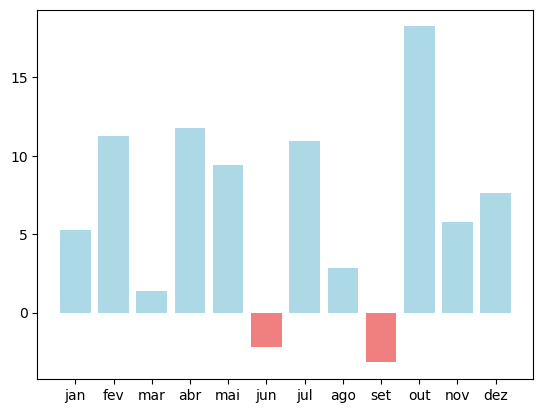

In [18]:
colors = ['lightcoral' if x <0 else 'lightblue' for x in mean]
plt.bar(mean.index, df_close_grouped.mean(), color=colors)
plt.savefig('bar-mean-pct-proj-cripto.png', dpi=300)

As variações anuais dos valores seguem o padrão que repete frequentemente. Nesse contexto, o mês de junho e, principalmente,setembro são meses indicados para a compra do ativo, visto que ele irá se valorizar no mês seguinte. 